# Models basats en espectrogrames: dades + selecció de model

Aquest notebook unifica dues etapes del bloc de **models basats en espectrogrames**
per a la classificació d'infants (lector típic vs. dislèxia) a partir de l'àudio de lectura:

1. **Extracció i generació de les dades** (Part 1). A partir dels WAV dels infants es generen
   els fragments compartits per tots els models del bloc: **formes d'ona** remostrejades (la dada base que cada *backbone* converteix internament).
2. **Selecció del millor model** (Part 2). Comparació honesta i barata de *backbones*
   congelats (PANNs CNN14 vs WavLM-base vs wav2vec2-base) i, després, dels caps de
   classificació (*linear probe* vs *mean-pool MIL* vs *Gated-Attention MIL*) sobre el
   *backbone* guanyador.
   
### Estratègia de fragmentació
Cada àudio es fragmenta en finestres de **5 s amb solapament del 50 % (stride 2,5 s)**,
de manera que cada infant aporta múltiples fragments que n'hereten l'etiqueta.

### Protocol de validació
Validació creuada estratificada **a nivell de subjecte** (cap fragment d'un mateix infant
apareix alhora en *train* i validació) + IC 95 % per *bootstrap* + *permutation test*. La
selecció del *backbone* i del cap de classificació es decideix **exclusivament** amb la CV
sobre el *train*. El **hold-out** s'inspecciona com a **comprovació secundària** durant la
comparació de *backbones* —cap decisió no en depèn— i s'avalua de manera **formal i
definitiva un sol cop**, sobre el model final ja seleccionat.

## 0. Entorn i dependències

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Ajusta aquest path al teu Drive
os.chdir('/content/drive/MyDrive/TFG')
print("Directori:", os.getcwd())

Mounted at /content/drive
Directori: /content/drive/.shortcut-targets-by-id/1Iq4-7Wejh98W55pRjmvllwL95W27DEex/TFG


In [2]:
!pip install librosa panns_inference torchaudio --quiet

### 0.1 Imports i configuració (paràmetres de dades)

In [ ]:
import sys, os, re, json, gc, math, unicodedata, warnings, time
warnings.filterwarnings("ignore")
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display

import torch

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
from utils.data_loading import load_dataset

sns.set_theme(style="whitegrid", font_scale=1.1)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

OUTPUTS    = ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)
AUDIO_ROOT = ROOT / "processed_data"
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Paràmetres dels espectrogrames Mel (representació espectral base) ──
SR         = 16_000
N_FFT      = 1024
HOP_LENGTH = 256
N_MELS     = 128

# ── Paràmetres de fragmentació (compartits per tot el bloc) ──
WINDOW_S       = 5.0
STRIDE_S       = 2.5
WINDOW_SAMPLES = int(WINDOW_S * SR)
STRIDE_SAMPLES = int(STRIDE_S * SR)
T_FIXED        = WINDOW_SAMPLES // HOP_LENGTH + 1   # ~313 frames
STRIDE_FRAMES  = STRIDE_SAMPLES // HOP_LENGTH       # ~156 frames

print(f"Root: {ROOT}")
print(f"PyTorch: {torch.__version__} | librosa: {librosa.__version__} | device: {DEVICE}")
print(f"Fragment mel: ({N_MELS}, {T_FIXED})  |  stride: {STRIDE_FRAMES} frames")

Root: /content/drive/.shortcut-targets-by-id/1Iq4-7Wejh98W55pRjmvllwL95W27DEex/TFG
PyTorch: 2.11.0+cu128 | librosa: 0.11.0 | device: cuda
Fragment mel: (128, 313)  |  stride: 156 frames


## 1. Extracció i generació de les dades

Es construeix el dataset de fragments compartit pels models del bloc:

- **Mapatge** WAV → infant, respectant exactament el *split* hold-out del notebook tabular (`06`).
- **Espectrogrames mel** (`mel_fragments.npz`): representació espectral i font de les
  etiquetes/grups/splits (`y_all`, `g_all`, `s_all`).
- **Formes d'ona a 32 kHz** (`panns_raw_waveforms.npy`): la dada base que tots els *backbones*
  d'àudio (PANNs, WavLM, wav2vec2) converteixen en el seu propi espectrograma, sincronitzada 1:1
  amb els fragments mel.

### 1.1 Mapatge fitxers WAV → infants

In [4]:
# Càrrega respectant la mateixa divisió hold-out que el notebook tabular.
SPLIT_PATH = OUTPUTS / "holdout_split.json"
assert SPLIT_PATH.exists(), (
    f"No es troba {SPLIT_PATH}. Cal executar primer 06_model_tabular.ipynb."
)

data_info = load_dataset(random_state=RANDOM_STATE, split_path=SPLIT_PATH)
assert data_info["split_source"] == "loaded"

df_train_meta = data_info["df_train"].assign(split="train")
df_hold_meta  = data_info["df_hold"].assign(split="hold")
df_meta = pd.concat([df_train_meta, df_hold_meta], ignore_index=True)

print(f"Divisió: {data_info['split_source']} des de {SPLIT_PATH.name}")
print(f"Infants totals: {len(df_meta)}")
print(f"  Entrenament: {len(df_train_meta)}  |  Hold-out: {len(df_hold_meta)}")
print(f"  Dislèxia (train): {(df_train_meta['dislexia']==1).sum()}")
print(f"  Dislèxia (hold):  {(df_hold_meta['dislexia']==1).sum()}")


def _norm(s: str) -> str:
    return unicodedata.normalize("NFC", s)


def find_wavs_for_child(nom: str, escola: str, classe: str,
                        is_dys: bool, audio_root: Path) -> list:
    """Cerca fitxers WAV per a un infant a la carpeta escola/classe.

    Extreu el codi de nom del stem (fins al primer dígit, sense prefix D_),
    el normalitza amb NFC i el compara amb la base del nom al CSV
    (sense sufixos numèrics de desambiguació com '3A').
    """
    folder = audio_root / escola / classe
    if not folder.exists():
        return []

    # Base del nom CSV sense sufixos de classe (p.ex. "Ona3A" → "Ona")
    nom_base = _norm(re.sub(r"[0-9]+[A-Za-z]*$", "", nom).strip())

    found = []
    for f in folder.iterdir():
        if not f.suffix.lower() == ".wav":
            continue
        stem = f.stem
        # Filtre pel prefix de dislèxia
        if is_dys and not stem.startswith("D_"):
            continue
        if not is_dys and stem.startswith("D_"):
            continue
        # Extreu codi del nom del fitxer
        s = stem[2:] if stem.startswith("D_") else stem
        code = _norm(re.sub(r"\d+.*$", "", s).strip())
        if code == nom_base:
            found.append(f)
    return found


# Construir wav_records iterant sobre els infants (nom+escola+classe → carpeta correcta)
wav_records = []
no_wav      = []

for _, row in df_meta.iterrows():
    nom    = row["nom"]
    escola = row["escola"]
    classe = row["classe"]
    lbl    = int(row["dislexia"])
    split  = row["split"]

    wavs = find_wavs_for_child(nom, escola, classe, lbl == 1, AUDIO_ROOT)
    if not wavs:
        no_wav.append(f"{nom} ({escola}/{classe})")
        continue
    for wav in wavs:
        wav_records.append({
            "wav_path": wav,
            "nom":      nom,
            "child_id": f"{nom}|{escola}|{classe}",   # ← afegir
            "label":    lbl,
            "split":    split,
        })

print(f"\nTotal WAVs trobats: {len(wav_records)}")
if no_wav:
    print(f"Infants sense WAV ({len(no_wav)}): {no_wav}")

df_wav = pd.DataFrame([{k: v for k, v in r.items() if k != "wav_path"}
                       for r in wav_records])
print("\nDistribució WAVs per split i etiqueta:")
print(df_wav.groupby(["split", "label"]).size().unstack(fill_value=0))

# Verificació: cap fitxer WAV als dos splits alhora
paths_train = set(r["wav_path"] for r in wav_records if r["split"] == "train")
paths_hold  = set(r["wav_path"] for r in wav_records if r["split"] == "hold")
overlap_paths = paths_train & paths_hold
assert not overlap_paths, f"Solapament de fitxers train/hold: {overlap_paths}"
print(f"OK — splits coherents amb {SPLIT_PATH.name}.")

Divisió: loaded des de holdout_split.json
Infants totals: 141
  Entrenament: 112  |  Hold-out: 29
  Dislèxia (train): 10
  Dislèxia (hold):  3

Total WAVs trobats: 141

Distribució WAVs per split i etiqueta:
label    0   1
split         
hold    26   3
train  102  10
OK — splits coherents amb holdout_split.json.


### 1.2 Espectrogrames mel per fragment

In [5]:
MEL_CACHE_PATH = OUTPUTS / "mel_fragments.npz"

if MEL_CACHE_PATH.exists():
    _d    = np.load(MEL_CACHE_PATH, allow_pickle=True)
    X_all = _d["X_all"]
    y_all = _d["y_all"]
    g_all = _d["g_all"]
    s_all = _d["s_all"]
    print(f"Fragments mel carregats del cache: {X_all.shape}  ({MEL_CACHE_PATH.name})")
else:
    print("Calculant espectrogrames Mel (pot trigar ...)")

    # Cache d'espectrogrames complets per WAV
    mel_cache = {}
    for rec in wav_records:
        p = rec["wav_path"]
        if p not in mel_cache:
            y_audio, _ = librosa.load(p, sr=SR, mono=True)
            mel = librosa.feature.melspectrogram(
                y=y_audio, sr=SR, n_mels=N_MELS,
                n_fft=N_FFT, hop_length=HOP_LENGTH,
            )
            mel_cache[p] = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
    print(f"  Espectrogrames calculats: {len(mel_cache)}")

    # Generar fragments
    fragments = []
    for rec in wav_records:
        mel_db  = mel_cache[rec["wav_path"]]   # (128, T_audio)
        T_audio = mel_db.shape[1]
        n_added = 0

        start = 0
        while start + T_FIXED <= T_audio:
            fragments.append({
                "mel":   mel_db[:, start:start + T_FIXED].copy(),
                "nom":   rec["nom"],
                "label": rec["label"],
                "child_id": rec["child_id"],
                "split": rec["split"],
            })
            start  += STRIDE_FRAMES
            n_added += 1

        # Si l'àudio és massa curt per a un fragment complet, emplenar amb silenci
        if n_added == 0:
            pad = T_FIXED - T_audio
            frag = np.pad(mel_db, ((0, 0), (0, pad)),
                          mode="constant", constant_values=-80.0)
            fragments.append({
                "mel":   frag.astype(np.float32),
                "nom":   rec["nom"],
                "label": rec["label"],
                "child_id": rec["child_id"],
                "split": rec["split"],
            })

    print(f"  Total fragments generats: {len(fragments)}")

    # Arrays finals
    X_all = np.stack([f["mel"]   for f in fragments]).astype(np.float32)
    y_all = np.array([f["label"] for f in fragments], dtype=np.int64)
    g_all = np.array([f["child_id"]   for f in fragments])
    s_all = np.array([f["split"] for f in fragments])

    del mel_cache, fragments

    np.savez_compressed(MEL_CACHE_PATH, X_all=X_all, y_all=y_all, g_all=g_all, s_all=s_all)
    print(f"  Fragments mel desats a {MEL_CACHE_PATH.name}")

train_mask = s_all == "train"
hold_mask  = s_all == "hold"

X_train = X_all[train_mask];  y_train = y_all[train_mask];  g_train = g_all[train_mask]
X_hold  = X_all[hold_mask];   y_hold  = y_all[hold_mask];   g_hold  = g_all[hold_mask]

pos_weight_train = (y_train == 0).sum() / max(1, (y_train == 1).sum())

print(f"\nDataset de fragments:")
print(f"  Train: {len(X_train)} fragments  ({y_train.sum()} dislèxia)")
print(f"  Hold:  {len(X_hold)}  fragments  ({y_hold.sum()} dislèxia)")
print(f"  Forma de cada fragment: {X_train.shape[1:]}")
print(f"  pos_weight CNN: {pos_weight_train:.2f}")


Calculant espectrogrames Mel (pot trigar ...)
  Espectrogrames calculats: 141
  Total fragments generats: 3544
  Fragments mel desats a mel_fragments.npz

Dataset de fragments:
  Train: 2909 fragments  (440 dislèxia)
  Hold:  635  fragments  (116 dislèxia)
  Forma de cada fragment: (128, 313)
  pos_weight CNN: 5.61


### 1.3 Paràmetres i checkpoint de PANNs CNN14

In [6]:
# Paràmetres del front-end de PANNs CNN14 (també els reutilitza la Part 2).
PANNS_SR          = 32000
PANNS_WINDOW_SIZE = 1024
PANNS_HOP_SIZE    = 320
PANNS_MEL_BINS    = 64
PANNS_FMIN        = 50
PANNS_FMAX        = 14000
PANNS_EMBED_DIM   = 2048

BATCH_SIZE_FEAT   = 64       # batch per a l'extracció de features
PANNS_FEAT_CACHE  = OUTPUTS / "panns_features_all.npy"
PANNS_WAV_CACHE   = OUTPUTS / "panns_raw_waveforms.npy"

PANNS_CKPT_NAME   = "Cnn14_mAP=0.431.pth"
PANNS_CKPT_PATH   = OUTPUTS / PANNS_CKPT_NAME
PANNS_CKPT_URL    = f"https://zenodo.org/record/3987831/files/{PANNS_CKPT_NAME}?download=1"
print("Paràmetres PANNs definits.")

Paràmetres PANNs definits.


### 1.4 Formes d'ona crues a 32 kHz

Tots els *backbones* comparats calculen el seu propi espectrograma a partir de la forma d'ona,
de manera que la dada base compartida és el *waveform* remostrejat a 32 kHz. Els fragments
queden **sincronitzats 1:1** amb els fragments mel (mateix ordre, mateixos `child_id`/`label`/`split`).

In [7]:
# ── Generació (o càrrega) dels fragments d'ona a 32 kHz ──
if PANNS_WAV_CACHE.exists():
    print("Carregant fragments d'àudio crus des de disc...")
    X_wav_all = np.load(PANNS_WAV_CACHE)
    print(f"  Fragments carregats: {X_wav_all.shape}")
else:
    print("Generant fragments d'àudio cru a 32 kHz...")
    WINDOW_SAMPLES_32 = int(WINDOW_S * PANNS_SR)   # 5 s * 32000 = 160000

    wav32_cache = {}
    for rec in wav_records:
        p = rec["wav_path"]
        if p not in wav32_cache:
            y32, _ = librosa.load(p, sr=PANNS_SR, mono=True)
            wav32_cache[p] = y32.astype(np.float32)

    # Nombre de fragments per infant (idèntic al comptatge dels fragments mel)
    _child_frag_counter = Counter(g_all)
    _seen = {}
    frag_count_per_rec = []
    for rec in wav_records:
        cid = rec["child_id"]
        if cid not in _seen:
            _seen[cid] = _child_frag_counter[cid]
            frag_count_per_rec.append(_child_frag_counter[cid])
        else:
            frag_count_per_rec.append(0)

    raw_fragments = []
    for rec, n_frags in zip(wav_records, frag_count_per_rec):
        if n_frags == 0:
            continue
        y32 = wav32_cache[rec["wav_path"]]
        n32 = len(y32)
        if n_frags == 1 and n32 < WINDOW_SAMPLES_32:
            raw_fragments.append(
                np.pad(y32, (0, WINDOW_SAMPLES_32 - n32)).astype(np.float32))
        else:
            for i in range(n_frags):
                start_32 = int(round(i * STRIDE_S * PANNS_SR))
                end_32   = start_32 + WINDOW_SAMPLES_32
                if end_32 <= n32:
                    wav_frag = y32[start_32:end_32].copy()
                else:
                    wav_frag = np.pad(y32[start_32:], (0, end_32 - n32)).astype(np.float32)
                raw_fragments.append(wav_frag.astype(np.float32))

    assert len(raw_fragments) == len(X_all), (
        f"Desajust: {len(raw_fragments)} fragments d'ona vs {len(X_all)} de mel.")

    X_wav_all = np.stack(raw_fragments).astype(np.float32)
    del wav32_cache, raw_fragments
    print(f"  Fragments d'ona: {X_wav_all.shape}  (sincronitzats amb mel \u2713)")

    np.save(PANNS_WAV_CACHE, X_wav_all)
    print(f"  Desats a {PANNS_WAV_CACHE.name}")

Generant fragments d'àudio cru a 32 kHz...
  Fragments d'ona: (3544, 160000)  (sincronitzats amb mel ✓)
  Desats a panns_raw_waveforms.npy


### 1.5 Inspecció visual de les dades generades

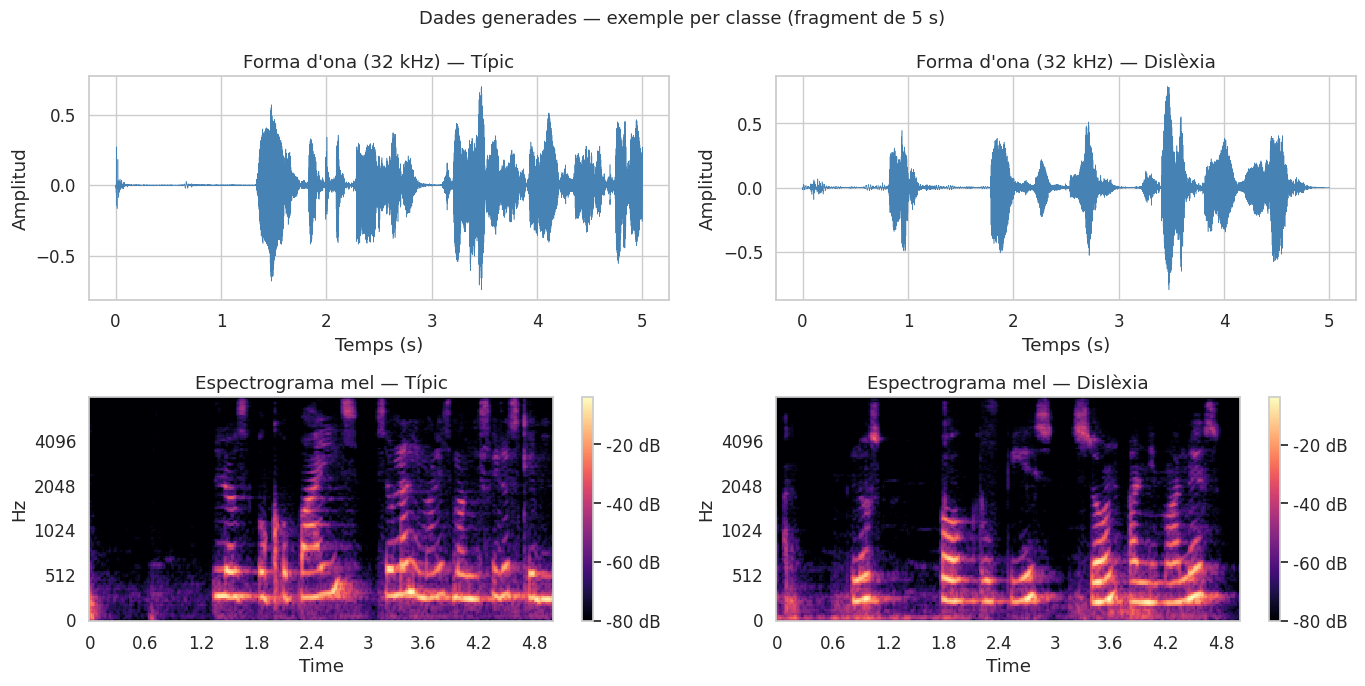

Resum del dataset de fragments:
  Fragments totals : 3544
  Forma mel        : (128, 313)  (n_mels x frames)
  Forma ona (32k)  : (160000,)
  Train: 2909 frags  |  Hold: 635 frags


In [8]:
# ── Exemple d'un fragment de cada classe: forma d'ona + espectrograma mel ──
def _first_subject_with_label(lbl):
    return np.unique(g_all[y_all == lbl])[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for col, lbl in enumerate([0, 1]):
    cid    = _first_subject_with_label(lbl)
    idx    = np.where(g_all == cid)[0][0]      # primer fragment del subjecte
    classe = "Dislèxia" if lbl == 1 else "Típic"

    axes[0, col].plot(np.linspace(0, WINDOW_S, X_wav_all.shape[1]),
                      X_wav_all[idx], lw=0.4, color="steelblue")
    axes[0, col].set_title(f"Forma d'ona (32 kHz) — {classe}")
    axes[0, col].set_xlabel("Temps (s)"); axes[0, col].set_ylabel("Amplitud")

    img = librosa.display.specshow(X_all[idx], sr=SR, hop_length=HOP_LENGTH,
                                   x_axis="time", y_axis="mel",
                                   ax=axes[1, col], cmap="magma")
    axes[1, col].set_title(f"Espectrograma mel — {classe}")
    fig.colorbar(img, ax=axes[1, col], format="%+2.0f dB")

plt.suptitle("Dades generades — exemple per classe (fragment de 5 s)", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / "data_examples.pdf", bbox_inches="tight")
plt.show()

print("Resum del dataset de fragments:")
print(f"  Fragments totals : {len(X_all)}")
print(f"  Forma mel        : {X_all.shape[1:]}  (n_mels x frames)")
print(f"  Forma ona (32k)  : {X_wav_all.shape[1:]}")
print(f"  Train: {int(train_mask.sum())} frags  |  Hold: {int(hold_mask.sum())} frags")

## 2. Selecció del millor model

Decisió en dues etapes, sempre amb el mateix protocol (CV de subjecte + IC *bootstrap* +
*permutation test*) i amb el **hold-out intacte** fins al final:

1. **Quin *backbone*** congelat separa millor les classes? (PANNs vs WavLM vs wav2vec2),
   avaluat amb un *linear probe* per subjecte — determinista, eficient en mostra i ràpid.
2. **Quin cap de classificació** sobre el *backbone* guanyador? (*linear probe* vs *mean-pool MIL*
   vs *Gated-Attention MIL*).

> Aquesta part reaprofita les caches de la Part 1. Si s'executa el notebook de dalt a baix,
> les troba ja a `outputs/`.

### 2.1 Comparació de *backbones* (PANNs vs WavLM vs wav2vec2)

In [9]:
# ── Imports i configuració ──────────────────────────────────────
import os, gc, math, time, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchaudio
import torchaudio.functional as taF

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

ROOT    = Path.cwd()
OUTPUTS = ROOT / "outputs"
OUTPUTS.mkdir(parents=True, exist_ok=True)
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("ROOT:", ROOT)
print("torch", torch.__version__, "| torchaudio", torchaudio.__version__, "| device", DEVICE)

# ── PANNs (per si cal re-extreure; si hi ha cache, no s'usa) ──────
PANNS_SR          = 32000
PANNS_WINDOW_SIZE = 1024
PANNS_HOP_SIZE    = 320
PANNS_MEL_BINS    = 64
PANNS_FMIN        = 50
PANNS_FMAX        = 14000
PANNS_CKPT_NAME   = "Cnn14_mAP=0.431.pth"
PANNS_CKPT_PATH   = OUTPUTS / PANNS_CKPT_NAME
PANNS_CKPT_URL    = f"https://zenodo.org/record/3987831/files/{PANNS_CKPT_NAME}?download=1"

# ── Configuració de la comparació ────────────────────────────────
WAV_SR_IN  = PANNS_SR        # SR dels waveforms cachejats (32 kHz)
SPEECH_LAYER = -1            # capa del transformer a usar (-1 = última). Pots
                            # provar capes intermèdies (p.ex. 6) per prosòdia.
EXTRACT_BATCH = 16          # mida de batch per a l'extracció (puja amb GPU gran)

CMP_CFG = {
    "n_splits": 5,          # folds de la CV de subjecte (= OUTER_SPLITS del 07b)
    "seeds":    [0, 1, 2],  # llavors de CV (mateixes per obs i permutació)
    "C":        0.1,        # regularització L2 del LogReg (forta; 768/2048 dims)
    "n_perm":   500,        # permutacions per backbone
    "boot_n":   2000,       # rèpliques bootstrap per als IC
    "perm_seed": 0,
}
print("Comparació:", CMP_CFG)

ROOT: /content/drive/.shortcut-targets-by-id/1Iq4-7Wejh98W55pRjmvllwL95W27DEex/TFG
torch 2.11.0+cu128 | torchaudio 2.11.0+cu128 | device cuda
Comparació: {'n_splits': 5, 'seeds': [0, 1, 2], 'C': 0.1, 'n_perm': 500, 'boot_n': 2000, 'perm_seed': 0}


In [10]:
# ── Càrrega dels caches del notebook 07b ─────────────────────────
MEL_CACHE  = OUTPUTS / "mel_fragments.npz"
WAV_CACHE  = OUTPUTS / "panns_raw_waveforms.npy"
PANNS_FEAT = OUTPUTS / "panns_features_all.npy"

assert MEL_CACHE.exists(), f"Falta {MEL_CACHE} (executa el 07b fins a la cel·la dels fragments mel)."
assert WAV_CACHE.exists(), f"Falta {WAV_CACHE} (executa el 07b fins a la cel·la dels waveforms crus)."

_d    = np.load(MEL_CACHE, allow_pickle=True)
y_all = _d["y_all"]; g_all = _d["g_all"]; s_all = _d["s_all"]
X_wav_all = np.load(WAV_CACHE)            # (N_frags, 160000) a 32 kHz

assert len(X_wav_all) == len(y_all) == len(g_all) == len(s_all), "Desalineament de caches!"
train_mask = s_all == "train"
hold_mask  = s_all == "hold"

subj_train = np.unique(g_all[train_mask])
subj_hold  = np.unique(g_all[hold_mask])
y_subj_train = np.array([int(y_all[g_all == s][0]) for s in subj_train])
y_subj_hold  = np.array([int(y_all[g_all == s][0]) for s in subj_hold])

print(f"Fragments totals: {len(X_wav_all)}  ({X_wav_all.shape[1]} mostres = "
      f"{X_wav_all.shape[1]/PANNS_SR:.1f}s @ {PANNS_SR} Hz)")
print(f"Subjectes TRAIN: {len(subj_train)}  (positius: {y_subj_train.sum()})")
print(f"Subjectes HOLD : {len(subj_hold)}   (positius: {y_subj_hold.sum()})")

Fragments totals: 3544  (160000 mostres = 5.0s @ 32000 Hz)
Subjectes TRAIN: 112  (positius: 10)
Subjectes HOLD : 29   (positius: 3)


In [11]:
# ── Extractors de features (amb cache per backbone) ──────────────

def extract_speech(bundle, X_wav32, layer=SPEECH_LAYER, batch=EXTRACT_BATCH,
                   sr_in=WAV_SR_IN, device=DEVICE):
    """Embedding per fragment d'un model SSL de parla (torchaudio).

    Remostreja 32 kHz -> sr del model (16 kHz), passa el waveform pel model
    CONGELAT, agafa la capa `layer` i fa MEAN-POOL sobre el temps.
    Retorna (N_frags, dim).
    """
    model = bundle.get_model().to(device).eval()
    sr_out = bundle.sample_rate
    embs = []
    with torch.no_grad():
        for i in range(0, len(X_wav32), batch):
            w = torch.from_numpy(X_wav32[i:i + batch]).float().to(device)
            w = taF.resample(w, sr_in, sr_out)
            feats, _ = model.extract_features(w)     # llista de (B, T, dim)
            h = feats[layer]                          # (B, T, dim)
            embs.append(h.mean(dim=1).cpu().numpy())  # mean-pool temporal
            if (i // batch) % 25 == 0:
                print(f"  {min(i+batch,len(X_wav32))}/{len(X_wav32)}", flush=True)
    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()
    gc.collect()
    return np.vstack(embs).astype(np.float32)


def extract_panns(X_wav32, batch=64, device=DEVICE):
    """Embedding PANNs CNN14 (2048-dim) per fragment. Mirall de la cel·la 17."""
    from panns_inference.models import Cnn14
    if not PANNS_CKPT_PATH.exists():
        print("Descarregant pesos PANNs CNN14...")
        urllib.request.urlretrieve(PANNS_CKPT_URL, PANNS_CKPT_PATH)
    net = Cnn14(sample_rate=PANNS_SR, window_size=PANNS_WINDOW_SIZE,
                hop_size=PANNS_HOP_SIZE, mel_bins=PANNS_MEL_BINS,
                fmin=PANNS_FMIN, fmax=PANNS_FMAX, classes_num=527)
    net.load_state_dict(torch.load(PANNS_CKPT_PATH, map_location=device)["model"])
    net.eval().to(device)
    for p in net.parameters():
        p.requires_grad = False
    embs = []
    with torch.no_grad():
        for i in range(0, len(X_wav32), batch):
            w = torch.from_numpy(X_wav32[i:i + batch]).float().to(device)
            embs.append(net(w)["embedding"].cpu().numpy())
    del net
    if device.type == "cuda":
        torch.cuda.empty_cache()
    gc.collect()
    return np.vstack(embs).astype(np.float32)


def get_embeddings(name):
    """Carrega del cache o extreu els embeddings d'un backbone."""
    cache = OUTPUTS / f"emb_{name}.npy"
    if cache.exists():
        E = np.load(cache)
        print(f"[CACHE] {name}: {E.shape}")
        return E
    print(f"[EXTRACT] {name} ...")
    t0 = time.time()
    if name == "PANNs":
        if PANNS_FEAT.exists():
            E = np.load(PANNS_FEAT)
            print(f"  (reaprofitant {PANNS_FEAT.name}: {E.shape})")
        else:
            E = extract_panns(X_wav_all)
    elif name == "WavLM":
        E = extract_speech(torchaudio.pipelines.WAVLM_BASE, X_wav_all)
    elif name == "wav2vec2":
        E = extract_speech(torchaudio.pipelines.WAV2VEC2_BASE, X_wav_all)
    else:
        raise ValueError(name)
    np.save(cache, E)
    print(f"  {name}: {E.shape}  ({time.time()-t0:.0f}s)  -> {cache.name}")
    return E

In [12]:
# ── Extracció dels tres backbones (pot trigar uns minuts amb GPU) ─
BACKBONES = ["PANNs", "WavLM", "wav2vec2"]
EMB = {name: get_embeddings(name) for name in BACKBONES}
for name in BACKBONES:
    assert len(EMB[name]) == len(y_all), f"{name}: desalineament amb les etiquetes"
print("\nEmbeddings llestos:", {n: EMB[n].shape for n in BACKBONES})

[EXTRACT] PANNs ...
Descarregant pesos PANNs CNN14...
  PANNs: (3544, 2048)  (61s)  -> emb_PANNs.npy
[EXTRACT] WavLM ...
Downloading: "https://download.pytorch.org/torchaudio/models/wavlm_base.pth" to /root/.cache/torch/hub/checkpoints/wavlm_base.pth


100%|██████████| 360M/360M [00:01<00:00, 278MB/s]


  16/3544
  416/3544
  816/3544
  1216/3544
  1616/3544
  2016/3544
  2416/3544
  2816/3544
  3216/3544
  WavLM: (3544, 768)  (10s)  -> emb_WavLM.npy
[EXTRACT] wav2vec2 ...
Downloading: "https://download.pytorch.org/torchaudio/models/wav2vec2_fairseq_base_ls960.pth" to /root/.cache/torch/hub/checkpoints/wav2vec2_fairseq_base_ls960.pth


100%|██████████| 360M/360M [00:01<00:00, 302MB/s]


  16/3544
  416/3544
  816/3544
  1216/3544
  1616/3544
  2016/3544
  2416/3544
  2816/3544
  3216/3544
  wav2vec2: (3544, 768)  (9s)  -> emb_wav2vec2.npy

Embeddings llestos: {'PANNs': (3544, 2048), 'WavLM': (3544, 768), 'wav2vec2': (3544, 768)}


In [13]:
# ── Motor de comparació: linear probe + bootstrap + permutació ───

def meanpool_subjects(X, groups, subjects):
    """Un embedding per subjecte = mitjana dels seus fragments."""
    return np.vstack([X[groups == s].mean(axis=0) for s in subjects])


def probe_oof(Xs, ys, n_splits, seeds, C):
    """Prob. OOF d'un linear probe (StandardScaler + LogReg L2), promitjant
    sobre `seeds`. Sense fuita: scaler i LogReg per fold. Retorna
    (auc_roc, auc_pr, oof_probs)."""
    ys = np.asarray(ys).astype(int)
    n = len(ys); ps = np.zeros(n); pc = np.zeros(n)
    for sd in seeds:
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=sd)
        for tr, va in skf.split(Xs, ys):
            sc = StandardScaler().fit(Xs[tr])
            lr = LogisticRegression(C=C, max_iter=2000, class_weight="balanced")
            lr.fit(sc.transform(Xs[tr]), ys[tr])
            ps[va] += lr.predict_proba(sc.transform(Xs[va]))[:, 1]
            pc[va] += 1
    oof = ps / np.maximum(pc, 1)
    return roc_auc_score(ys, oof), average_precision_score(ys, oof), oof


def bootstrap_ci(yt, yp, fn, n=2000, seed=0):
    rng = np.random.RandomState(seed)
    yt = np.asarray(yt); yp = np.asarray(yp)
    pt = fn(yt, yp); vals = []; N = len(yt)
    for _ in range(n):
        idx = rng.randint(0, N, N)
        if len(np.unique(yt[idx])) < 2:
            continue
        try:
            vals.append(fn(yt[idx], yp[idx]))
        except ValueError:
            continue
    if not vals:
        return pt, float("nan"), float("nan")
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return pt, float(lo), float(hi)


def permutation_test(Xs, ys, cfg):
    """Permutation test del probe. Barreja etiquetes de subjecte i recalcula
    l'AUC OOF amb el MATEIX estimador. Retorna dict amb observat, nul·la i p."""
    obs_r, obs_a, _ = probe_oof(Xs, ys, cfg["n_splits"], cfg["seeds"], cfg["C"])
    rng = np.random.RandomState(cfg["perm_seed"])
    nr = np.empty(cfg["n_perm"]); na = np.empty(cfg["n_perm"])
    for i in range(cfg["n_perm"]):
        yp = rng.permutation(ys)
        r, a, _ = probe_oof(Xs, yp, cfg["n_splits"], cfg["seeds"], cfg["C"])
        nr[i] = r; na[i] = a
    p_r = (1 + np.sum(nr >= obs_r)) / (1 + cfg["n_perm"])
    p_a = (1 + np.sum(na >= obs_a)) / (1 + cfg["n_perm"])
    return dict(roc=obs_r, ap=obs_a, p_roc=p_r, p_ap=p_a, null_roc=nr, null_ap=na)

In [14]:
# ── Executar la comparació sobre els subjectes de TRAIN ──────────
# (el hold-out es manté intacte; es comprova a part més avall)
print("Comparació de backbones — CV de subjecte sobre el TRAIN")
print("=" * 70)

cmp_results = {}
for name in BACKBONES:
    Xs = meanpool_subjects(EMB[name][train_mask], g_all[train_mask], subj_train)
    _, _, oof = probe_oof(Xs, y_subj_train, CMP_CFG["n_splits"],
                          CMP_CFG["seeds"], CMP_CFG["C"])
    roc_pt, roc_lo, roc_hi = bootstrap_ci(y_subj_train, oof, roc_auc_score,
                                          n=CMP_CFG["boot_n"])
    ap_pt, ap_lo, ap_hi = bootstrap_ci(y_subj_train, oof, average_precision_score,
                                       n=CMP_CFG["boot_n"])
    perm = permutation_test(Xs, y_subj_train, CMP_CFG)
    cmp_results[name] = dict(
        dim=Xs.shape[1],
        roc=roc_pt, roc_ci=(roc_lo, roc_hi),
        ap=ap_pt, ap_ci=(ap_lo, ap_hi),
        p_roc=perm["p_roc"], p_ap=perm["p_ap"],
        null_roc=perm["null_roc"], null_ap=perm["null_ap"], oof=oof)
    print(f"  {name} fet (dim={Xs.shape[1]})")

# ── Taula resum ──────────────────────────────────────────────────
print("\n" + "=" * 70)
print(f"{'Backbone':10s} {'Dim':>5s} {'AUC-ROC [IC95]':>22s} {'p':>7s} "
      f"{'AUC-PR [IC95]':>22s} {'p':>7s}")
print("-" * 78)
rows = []
for name in BACKBONES:
    r = cmp_results[name]
    print(f"{name:10s} {r['dim']:5d} "
          f"{r['roc']:.3f} [{r['roc_ci'][0]:.2f},{r['roc_ci'][1]:.2f}]".rjust(23),
          end="")
    print(f"{r['p_roc']:7.3f} "
          f"{r['ap']:.3f} [{r['ap_ci'][0]:.2f},{r['ap_ci'][1]:.2f}]".rjust(23),
          f"{r['p_ap']:7.3f}")
    rows.append(dict(backbone=name, dim=r["dim"], auc_roc=r["roc"],
                     roc_lo=r["roc_ci"][0], roc_hi=r["roc_ci"][1], p_roc=r["p_roc"],
                     auc_pr=r["ap"], p_ap=r["p_ap"]))

df_cmp = pd.DataFrame(rows)
df_cmp.to_csv(OUTPUTS / "backbone_comparison.csv", index=False)

winner = max(BACKBONES, key=lambda n: cmp_results[n]["roc"])
print("\n" + "=" * 70)
print(f"MILLOR per AUC-ROC (CV train): {winner}  "
      f"({cmp_results[winner]['roc']:.3f}, p={cmp_results[winner]['p_roc']:.3f})")
print("Mira si els IC se solapen: si ho fan, la diferència NO és concloent.")
print("=" * 70)

Comparació de backbones — CV de subjecte sobre el TRAIN
  PANNs fet (dim=2048)
  WavLM fet (dim=768)
  wav2vec2 fet (dim=768)

Backbone     Dim         AUC-ROC [IC95]       p          AUC-PR [IC95]       p
------------------------------------------------------------------------------
PANNs       2048 0.722 [0.53,0.90]  0.026 0.211 [0.10,0.43]   0.104
WavLM        768 0.912 [0.84,0.97]  0.002 0.520 [0.22,0.78]   0.002
wav2vec2     768 0.673 [0.48,0.85]  0.074 0.194 [0.08,0.42]   0.164

MILLOR per AUC-ROC (CV train): WavLM  (0.912, p=0.002)
Mira si els IC se solapen: si ho fan, la diferència NO és concloent.


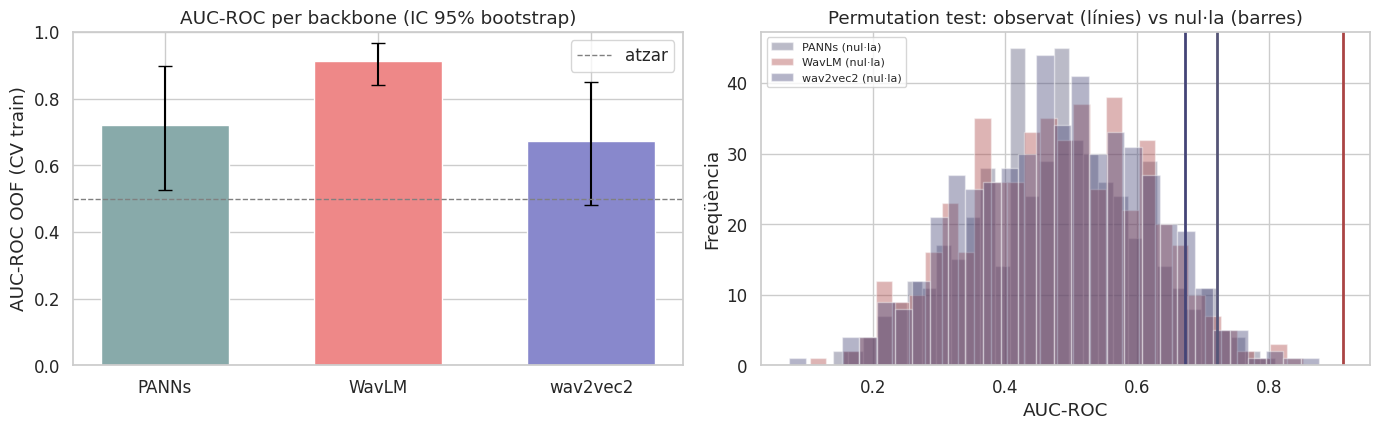

In [15]:
# ── Visualització: AUC amb IC + distribucions nul·les ────────────
fig = plt.figure(figsize=(14, 4.5))

# (1) AUC-ROC per backbone amb IC 95%
ax1 = fig.add_subplot(1, 2, 1)
xs = np.arange(len(BACKBONES))
vals = [cmp_results[n]["roc"] for n in BACKBONES]
los  = [cmp_results[n]["roc"] - cmp_results[n]["roc_ci"][0] for n in BACKBONES]
his  = [cmp_results[n]["roc_ci"][1] - cmp_results[n]["roc"] for n in BACKBONES]
ax1.bar(xs, vals, color=["#8aa", "#e88", "#88c"], width=0.6)
ax1.errorbar(xs, vals, yerr=[los, his], fmt="none", ecolor="black", capsize=5)
ax1.axhline(0.5, ls="--", color="gray", lw=1, label="atzar")
ax1.set_xticks(xs); ax1.set_xticklabels(BACKBONES)
ax1.set_ylabel("AUC-ROC OOF (CV train)"); ax1.set_ylim(0, 1)
ax1.set_title("AUC-ROC per backbone (IC 95% bootstrap)"); ax1.legend()

# (2) distribucions nul·les del permutation test (AUC-ROC)
ax2 = fig.add_subplot(1, 2, 2)
colors = {"PANNs": "#557", "WavLM": "#a44", "wav2vec2": "#447"}
for name in BACKBONES:
    ax2.hist(cmp_results[name]["null_roc"], bins=30, alpha=0.4,
             color=colors[name], label=f"{name} (nul·la)")
    ax2.axvline(cmp_results[name]["roc"], color=colors[name], lw=2)
ax2.set_xlabel("AUC-ROC"); ax2.set_ylabel("Freqüència")
ax2.set_title("Permutation test: observat (línies) vs nul·la (barres)")
ax2.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUTS / "backbone_comparison.pdf", bbox_inches="tight")
plt.show()

In [16]:
# ── Comprovació SECUNDÀRIA sobre el hold-out ─────────────────────
# El hold-out NO decideix el guanyador (s'ha decidit per CV de train),
# però confirma que el senyal no és un artefacte de la CV.
print("Comprovació hold-out (probe entrenat amb TOT el train) — secundària")
print("=" * 64)
for name in BACKBONES:
    Xtr = meanpool_subjects(EMB[name][train_mask], g_all[train_mask], subj_train)
    Xho = meanpool_subjects(EMB[name][hold_mask],  g_all[hold_mask],  subj_hold)
    sc = StandardScaler().fit(Xtr)
    lr = LogisticRegression(C=CMP_CFG["C"], max_iter=2000,
                            class_weight="balanced").fit(sc.transform(Xtr), y_subj_train)
    p_ho = lr.predict_proba(sc.transform(Xho))[:, 1]
    try:
        roc = roc_auc_score(y_subj_hold, p_ho)
        ap = average_precision_score(y_subj_hold, p_ho)
        print(f"  {name:10s}: hold-out AUC-ROC={roc:.3f}  AUC-PR={ap:.3f}  "
              f"(n={len(y_subj_hold)}, pos={int(y_subj_hold.sum())})")
    except ValueError:
        print(f"  {name:10s}: hold-out amb una sola classe; AUC indefinit.")
print("\nNota: amb pocs subjectes al hold-out aquests valors tenen molta")
print("variància; pren-los com a indici, no com a veredicte.")

Comprovació hold-out (probe entrenat amb TOT el train) — secundària
  PANNs     : hold-out AUC-ROC=0.782  AUC-PR=0.340  (n=29, pos=3)
  WavLM     : hold-out AUC-ROC=0.910  AUC-PR=0.610  (n=29, pos=3)
  wav2vec2  : hold-out AUC-ROC=0.654  AUC-PR=0.186  (n=29, pos=3)

Nota: amb pocs subjectes al hold-out aquests valors tenen molta
variància; pren-los com a indici, no com a veredicte.


## Conclusió: WavLM-base com a backbone

### Decisió

S'escull **WavLM-base** com a extractor de features. És l'únic backbone que mostra
senyal per damunt de l'atzar segons tots tres criteris alhora:

- **IC bootstrap** que exclou clarament el 0,5 (límit inferior 0,84). El de wav2vec2
  creua l'atzar (límit inferior 0,48) i el de PANNs hi queda just per damunt (0,53),
  tots dos amb intervals molt amplis.
- **Permutation test significatiu en AUC-ROC i AUC-PR alhora** (p = 0,002 en tots
  dos). PANNs només ho és en AUC-ROC (p = 0,026; p = 0,10 en AUC-PR) i wav2vec2 en
  cap de les dues (p = 0,07 i p = 0,16).
- **Coherència entre CV i hold-out** (0,912 vs 0,910): la concordança indica que
  l'estimació de CV no està inflada per la selecció del millor de tres i que el
  model generalitza a infants no vistos durant l'entrenament.

### Interpretació

El contrast entre WavLM i wav2vec2 és informatiu: tot i ser tots dos models
auto-supervisats de parla, només WavLM separa les classes. És consistent amb la
hipòtesi de domini — el preentrenament de WavLM, que incorpora modelatge de
parlant i robustesa al soroll, captura millor la prosòdia i la fluïdesa (els
marcadors de dislèxia) que el de wav2vec2, més orientat al contingut fonètic.
Les features d'AudioSet (PANNs), pensades per a esdeveniments sonors genèrics,
no assoleixen significació conjunta en totes dues mètriques. *Matís:* es va emprar l'última capa per a tots els models;
wav2vec2 podria millorar amb una capa intermèdia, però WavLM guanya igualment.

### Limitacions

El hold-out conté només 29 infants (3 positius), de manera que els seus valors
—especialment l'AUC-PR— tenen una variància elevada i s'han de prendre com a
confirmació qualitativa, no com a estimació de precisió. La xifra de referència
és l'AUC-ROC de CV amb el seu IC i el p-valor de permutació, confirmada pel
hold-out.

### Següent pas

Amb WavLM-base fixat, es passa a la selecció del cap de classificació sobre el
pipeline honest (linear probe vs mean-pool vs Gated-Attention MIL), comparant la
millora respecte al linear probe ja obtingut (AUC-ROC ≈ 0,91) i confirmant el
model final sobre el hold-out un sol cop.

## Selecció del cap de classificació — WavLM-base fixat

**Objectiu.** Comparar tres caps de classificació amb el backbone WavLM-base *congelat*:

| Cap | Agregació de fragments | Classificador | Entrenament |
|---|---|---|---|
| **Linear probe** | mean-pool (numpy) | LogReg L2 | sklearn (LBFGS) |
| **Mean-pool MIL** | mean-pool (PyTorch) | `nn.Linear` | Adam |
| **Gated-Attention MIL** | atenció gated (Ilse et al., NeurIPS 2018) | `nn.Linear` | Adam |

**Baseline.** El linear probe (AUC-ROC ≈ 0,91) ja s'ha calculat a la secció
anterior. Es reutilitza directament (`cmp_results["WavLM"]`) sense re-entrenar.

**Pipeline honest.** Per als caps neurals: `StandardScaler` fit *únicament*
sobre els fragments del fold de train, CV estratificada a nivell de subjecte
(5 folds, 3 seeds), `BCEWithLogitsLoss` amb pes de la classe positiva per
compensar el desequilibri. El **hold-out** s'usa una sola vegada, per al cap
guanyador, al final.

**Permutation test.** 99 permutacions amb entrenament lleuger (30 èpoques,
1 seed) per confirmar que el senyal és real i no un artefacte del CV.

In [17]:
import torch.nn as nn

# ── Configuració del cap de classificació ────────────────────────
HEAD_CFG = {
    "n_splits":       5,
    "seeds":          [0, 1, 2],
    "n_epochs":       80,
    "lr":             1e-3,
    "wd":             1e-4,
    "att_dim":        128,     # dimensió de l'atenció per a GAMIL
    "n_perm":         99,      # permutacions (lleuger; caps neurals més cars)
    "n_epochs_perm":  30,      # èpoques per permutació (fast=True)
    "seeds_perm":     [0],     # una sola seed per al permutation test
    "perm_seed":      42,
    "boot_n":         2000,
    "in_dim":         768,     # WavLM-base output dim
}

# ── Construir bosses (bags) per subjecte ─────────────────────────
E_wl = EMB["WavLM"]   # (N_frags, 768), ja carregat de l'emb_WavLM.npy
bags_train = {s: E_wl[(g_all == s) & train_mask] for s in subj_train}
bags_hold  = {s: E_wl[(g_all == s) & hold_mask]  for s in subj_hold}

sizes = [len(v) for v in bags_train.values()]
print(f"Bosses train : {len(bags_train)} subjectes  "
      f"(frags/subjecte: min={min(sizes)}, màx={max(sizes)}, "
      f"mitj={np.mean(sizes):.1f} ± {np.std(sizes):.1f})")
print(f"Bosses hold  : {len(bags_hold)} subjectes")
print(f"HEAD_CFG     : {HEAD_CFG}")

Bosses train : 112 subjectes  (frags/subjecte: min=8, màx=77, mitj=26.0 ± 12.0)
Bosses hold  : 29 subjectes
HEAD_CFG     : {'n_splits': 5, 'seeds': [0, 1, 2], 'n_epochs': 80, 'lr': 0.001, 'wd': 0.0001, 'att_dim': 128, 'n_perm': 99, 'n_epochs_perm': 30, 'seeds_perm': [0], 'perm_seed': 42, 'boot_n': 2000, 'in_dim': 768}


In [18]:
# ── Definicions dels caps MIL (sobre WavLM congelat) ─────────────

class MeanPoolMIL(nn.Module):
    """Agrega els fragments per MEAN-POOL uniforme i classifica amb
    una capa lineal (equivalent al linear probe però entrenat amb Adam)."""

    def __init__(self, in_dim: int = 768):
        super().__init__()
        self.classifier = nn.Linear(in_dim, 1)

    def forward(self, H: torch.Tensor) -> torch.Tensor:  # H: (K, D)
        z = H.mean(dim=0, keepdim=True)                  # (1, D)
        return self.classifier(z).squeeze()            # escalar


class GatedAttentionMIL(nn.Module):
    """Gated Attention MIL — Ilse et al. (NeurIPS 2018).

    Per a cada fragment k:
        A_k  = w⊤ ( tanh(V · h_k)  ⊙  σ(U · h_k) )
    Pesos d'atenció:   a = softmax(A)
    Representació bag: z = Σ_k  a_k · h_k
    Logit:             classifier(z)
    """

    def __init__(self, in_dim: int = 768, att_dim: int = 128):
        super().__init__()
        self.V          = nn.Linear(in_dim, att_dim)        # V matriu
        self.U          = nn.Linear(in_dim, att_dim)        # U matriu (gate)
        self.w          = nn.Linear(att_dim, 1, bias=False) # vector de puntuació
        self.classifier = nn.Linear(in_dim, 1)

    def forward(self, H: torch.Tensor) -> torch.Tensor:     # H: (K, D)
        A = self.w(torch.tanh(self.V(H)) * torch.sigmoid(self.U(H)))  # (K,1)
        A = torch.softmax(A, dim=0)                                    # (K,1)
        z = A.T @ H                                                    # (1,D)
        return self.classifier(z).squeeze()                          # escalar


HEAD_FACTORIES = {
    "MeanPool-MIL":       lambda: MeanPoolMIL(in_dim=HEAD_CFG["in_dim"]),
    "GatedAttention-MIL": lambda: GatedAttentionMIL(
                              in_dim=HEAD_CFG["in_dim"],
                              att_dim=HEAD_CFG["att_dim"]),
}

# Resum de paràmetres
for name, fn in HEAD_FACTORIES.items():
    m = fn()
    n_params = sum(p.numel() for p in m.parameters())
    print(f"{name:22s}  params={n_params:,}")

MeanPool-MIL            params=769
GatedAttention-MIL      params=197,761


In [19]:
# ── Utilitats d'entrenament honest (CV de subjecte, sense fuita) ─

def run_cv_mil(bags: dict, subjects, labels, model_factory, cfg,
               fast: bool = False, device=DEVICE):
    """CV estratificada de subjecte per a un cap MIL PyTorch.

    Garantia de no-fuita:
      · StandardScaler fit ÚNICAMENT sobre fragments del fold de train.
      · El model s'inicialitza des de zero a cada fold.

    fast=True: menys èpoques i una sola seed (per al permutation test).
    Retorna (auc_roc, auc_pr, oof_probs) on oof_probs[i] és la prob.
    estimada per al subjecte i (promig sobre els seeds).
    """
    labels = np.asarray(labels).astype(int)
    n      = len(subjects)
    oof_p  = np.zeros(n)
    oof_c  = np.zeros(n)
    seeds  = cfg["seeds_perm"] if fast else cfg["seeds"]
    n_ep   = cfg["n_epochs_perm"] if fast else cfg["n_epochs"]

    for seed in seeds:
        rng = np.random.RandomState(seed)
        skf = StratifiedKFold(n_splits=cfg["n_splits"], shuffle=True,
                              random_state=seed)
        for tr_idx, va_idx in skf.split(np.arange(n), labels):
            # Scaler: fit sobre fragments del fold de train (sense fuita)
            X_tr = np.vstack([bags[subjects[i]] for i in tr_idx])
            sc   = StandardScaler().fit(X_tr)

            # Pes de classe: compensa desequilibri positiu/negatiu
            y_tr = labels[tr_idx]
            pw   = float((y_tr == 0).sum()) / max(float((y_tr == 1).sum()), 1.0)
            crit = nn.BCEWithLogitsLoss(
                pos_weight=torch.tensor(pw, dtype=torch.float32).to(device))

            model = model_factory().to(device)
            opt   = torch.optim.Adam(model.parameters(),
                                     lr=cfg["lr"], weight_decay=cfg["wd"])

            # Entrenament: una instància (bag) per pas de gradient
            model.train()
            for _ in range(n_ep):
                for k in rng.permutation(len(tr_idx)):
                    i  = tr_idx[k]
                    H  = torch.from_numpy(
                             sc.transform(bags[subjects[i]])
                         ).float().to(device)
                    y  = torch.tensor(float(labels[i]),
                                      dtype=torch.float32).to(device)
                    opt.zero_grad()
                    crit(model(H), y).backward()
                    opt.step()

            # Inferència al fold de validació
            model.eval()
            with torch.no_grad():
                for i in va_idx:
                    H = torch.from_numpy(
                            sc.transform(bags[subjects[i]])
                        ).float().to(device)
                    oof_p[i] += torch.sigmoid(model(H)).item()
                    oof_c[i] += 1

    oof = oof_p / np.maximum(oof_c, 1)
    return roc_auc_score(labels, oof), average_precision_score(labels, oof), oof


def perm_null_mil(bags, subjects, labels, model_factory, cfg, device=DEVICE):
    """Genera la distribució nul·la del permutation test (fast=True).

    Retorna (null_roc, null_ap) arrays de longitud cfg["n_perm"].
    """
    rng  = np.random.RandomState(cfg["perm_seed"])
    nr   = np.empty(cfg["n_perm"])
    na   = np.empty(cfg["n_perm"])
    labs = np.asarray(labels).astype(int)
    for i in range(cfg["n_perm"]):
        r, a, _ = run_cv_mil(bags, subjects, rng.permutation(labs),
                              model_factory, cfg, fast=True, device=device)
        nr[i] = r
        na[i] = a
        if (i + 1) % 10 == 0:
            print(f"  {i + 1}/{cfg['n_perm']}", end="  ", flush=True)
    print()
    return nr, na


print("Utilitats de CV i permutation test definides.")

Utilitats de CV i permutation test definides.


In [20]:
# ── Comparació de caps: CV + bootstrap IC + permutation test ─────
# El linear probe és el BASELINE (ja calculat). Els caps neurals
# s'entrenen aquí. Pot trigar 10–30 min sense GPU.

NEURAL_HEADS = ["MeanPool-MIL", "GatedAttention-MIL"]
head_results  = {}

# ── Baseline: linear probe (reutilitzat de la secció anterior) ───
_r = cmp_results["WavLM"]
head_results["Linear probe"] = dict(
    roc     = _r["roc"],      roc_ci  = _r["roc_ci"],
    ap      = _r["ap"],       ap_ci   = _r["ap_ci"],
    p_roc   = _r["p_roc"],    p_ap    = _r["p_ap"],
    null_roc= _r["null_roc"], null_ap = _r["null_ap"],
    oof     = _r["oof"],
)
print(f"{'Linear probe':22s}  AUC-ROC={_r['roc']:.3f}  (reutilitzat)\n")

# ── Caps neurals ─────────────────────────────────────────────────
for hname in NEURAL_HEADS:
    print(f"{'─'*60}")
    print(f"[{hname}]  CV de subjecte ({HEAD_CFG['n_splits']} folds × "
          f"{len(HEAD_CFG['seeds'])} seeds × {HEAD_CFG['n_epochs']} èpoques) …",
          flush=True)
    t0 = time.time()
    roc_pt, ap_pt, oof = run_cv_mil(bags_train, list(subj_train),
                                     y_subj_train, HEAD_FACTORIES[hname],
                                     HEAD_CFG, fast=False)
    t_cv = time.time() - t0

    roc_pt, roc_lo, roc_hi = bootstrap_ci(y_subj_train, oof, roc_auc_score,
                                           n=HEAD_CFG["boot_n"])
    ap_pt,  ap_lo,  ap_hi  = bootstrap_ci(y_subj_train, oof,
                                           average_precision_score,
                                           n=HEAD_CFG["boot_n"])
    print(f"  CV  ({t_cv:.0f}s)  AUC-ROC={roc_pt:.3f} [{roc_lo:.2f},{roc_hi:.2f}]  "
          f"AUC-PR={ap_pt:.3f} [{ap_lo:.2f},{ap_hi:.2f}]")

    print(f"  Permutation test ({HEAD_CFG['n_perm']} perm, fast) …", flush=True)
    t0 = time.time()
    nr, na = perm_null_mil(bags_train, list(subj_train), y_subj_train,
                           HEAD_FACTORIES[hname], HEAD_CFG)
    p_r = float((1 + (nr >= roc_pt).sum()) / (1 + HEAD_CFG["n_perm"]))
    p_a = float((1 + (na >= ap_pt).sum())  / (1 + HEAD_CFG["n_perm"]))
    print(f"  Perm ({time.time()-t0:.0f}s)  p_roc={p_r:.3f}  p_ap={p_a:.3f}")

    head_results[hname] = dict(
        roc     = roc_pt,        roc_ci  = (roc_lo, roc_hi),
        ap      = ap_pt,         ap_ci   = (ap_lo,  ap_hi),
        p_roc   = p_r,           p_ap    = p_a,
        null_roc= nr,            null_ap = na,
        oof     = oof,
    )

print(f"\n{'─'*60}")
print("Tots els caps processats.")

Linear probe            AUC-ROC=0.912  (reutilitzat)

────────────────────────────────────────────────────────────
[MeanPool-MIL]  CV de subjecte (5 folds × 3 seeds × 80 èpoques) …
  CV  (56s)  AUC-ROC=0.899 [0.81,0.97]  AUC-PR=0.601 [0.28,0.85]
  Permutation test (99 perm, fast) …
  10/99    20/99    30/99    40/99    50/99    60/99    70/99    80/99    90/99  
  Perm (655s)  p_roc=0.010  p_ap=0.010
────────────────────────────────────────────────────────────
[GatedAttention-MIL]  CV de subjecte (5 folds × 3 seeds × 80 èpoques) …
  CV  (92s)  AUC-ROC=0.896 [0.81,0.96]  AUC-PR=0.473 [0.22,0.81]
  Permutation test (99 perm, fast) …
  10/99    20/99    30/99    40/99    50/99    60/99    70/99    80/99    90/99  
  Perm (1105s)  p_roc=0.010  p_ap=0.010

────────────────────────────────────────────────────────────
Tots els caps processats.


In [21]:
# ── Taula resum i selecció del guanyador ─────────────────────────
ALL_CAPS = ["Linear probe", "MeanPool-MIL", "GatedAttention-MIL"]

print("=" * 86)
print(f"{'Cap':22s}  {'AUC-ROC [IC95]':>26s}  {'p':>6s}  "
      f"{'AUC-PR [IC95]':>26s}  {'p':>6s}")
print("-" * 86)
rows = []
for cname in ALL_CAPS:
    r = head_results[cname]
    roc_str = f"{r['roc']:.3f} [{r['roc_ci'][0]:.2f},{r['roc_ci'][1]:.2f}]"
    ap_str  = f"{r['ap']:.3f} [{r['ap_ci'][0]:.2f},{r['ap_ci'][1]:.2f}]"
    flag = " ◄" if r["roc"] == max(head_results[c]["roc"] for c in ALL_CAPS) else ""
    print(f"{cname:22s}  {roc_str:>26s}  {r['p_roc']:6.3f}  "
          f"{ap_str:>26s}  {r['p_ap']:6.3f}{flag}")
    rows.append(dict(
        cap     = cname,
        auc_roc = r["roc"],  roc_lo = r["roc_ci"][0], roc_hi = r["roc_ci"][1],
        p_roc   = r["p_roc"],
        auc_pr  = r["ap"],   ap_lo  = r["ap_ci"][0],  ap_hi  = r["ap_ci"][1],
        p_ap    = r["p_ap"],
    ))
print("=" * 86)

df_heads = pd.DataFrame(rows)
df_heads.to_csv(OUTPUTS / "head_comparison.csv", index=False)
print(f"\nResultats desats a {OUTPUTS / 'head_comparison.csv'}")

winner_name = max(ALL_CAPS, key=lambda n: head_results[n]["roc"])
baseline_roc = head_results["Linear probe"]["roc"]
delta        = head_results[winner_name]["roc"] - baseline_roc
ci_overlap   = (head_results[winner_name]["roc_ci"][0] <=
                head_results["Linear probe"]["roc_ci"][1])

print(f"\nMillor cap per AUC-ROC: {winner_name}")
print(f"  Δ respecte al linear probe: {delta:+.3f}")
print(f"  IC 95% se solapen amb linear probe: {ci_overlap}")
if ci_overlap:
    print("  → Diferència NO concloent; aplica principi de parsimònia.")
else:
    print("  → Diferència CONCLOENT (IC no se solapen).")

Cap                                 AUC-ROC [IC95]       p               AUC-PR [IC95]       p
--------------------------------------------------------------------------------------
Linear probe                     0.912 [0.84,0.97]   0.002           0.520 [0.22,0.78]   0.002 ◄
MeanPool-MIL                     0.899 [0.81,0.97]   0.010           0.601 [0.28,0.85]   0.010
GatedAttention-MIL               0.896 [0.81,0.96]   0.010           0.473 [0.22,0.81]   0.010

Resultats desats a /content/drive/.shortcut-targets-by-id/1Iq4-7Wejh98W55pRjmvllwL95W27DEex/TFG/outputs/head_comparison.csv

Millor cap per AUC-ROC: Linear probe
  Δ respecte al linear probe: +0.000
  IC 95% se solapen amb linear probe: True
  → Diferència NO concloent; aplica principi de parsimònia.


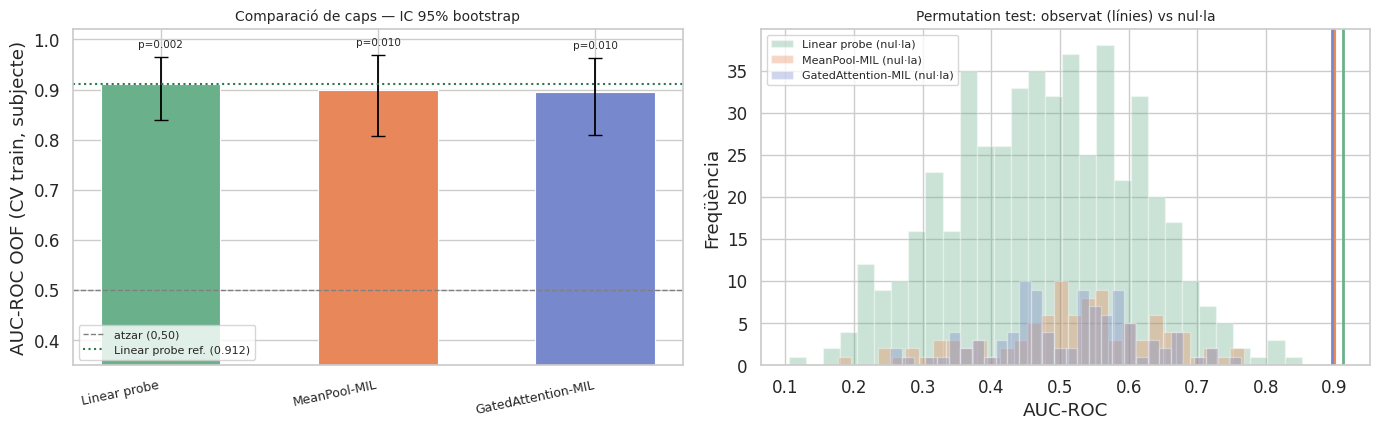

In [22]:
# ── Visualització: AUC-ROC + distribucions nul·les ───────────────
_colors = {
    "Linear probe":       "#6ab08a",
    "MeanPool-MIL":       "#e8885a",
    "GatedAttention-MIL": "#7888cc",
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# ── Panel 1: barres AUC-ROC + IC 95% bootstrap ──────────────────
xs   = np.arange(len(ALL_CAPS))
vals = [head_results[c]["roc"]             for c in ALL_CAPS]
los  = [head_results[c]["roc"] - head_results[c]["roc_ci"][0] for c in ALL_CAPS]
his  = [head_results[c]["roc_ci"][1] - head_results[c]["roc"] for c in ALL_CAPS]

ax1.bar(xs, vals, color=[_colors[c] for c in ALL_CAPS], width=0.55,
        edgecolor="white", linewidth=0.8)
ax1.errorbar(xs, vals, yerr=[los, his], fmt="none",
             ecolor="black", capsize=5, elinewidth=1.3)
ax1.axhline(0.5, ls="--", color="gray", lw=1, label="atzar (0,50)")
ax1.axhline(head_results["Linear probe"]["roc"], ls=":", color="#2a7a4f",
            lw=1.5,
            label=f"Linear probe ref. ({head_results['Linear probe']['roc']:.3f})")
ax1.set_xticks(xs)
ax1.set_xticklabels(ALL_CAPS, rotation=12, ha="right", fontsize=9)
ax1.set_ylabel("AUC-ROC OOF (CV train, subjecte)")
ax1.set_ylim(0.35, 1.02)
ax1.set_title("Comparació de caps — IC 95% bootstrap", fontsize=10)
ax1.legend(fontsize=8)

# Anotar p-valors de permutació
for x, cname in zip(xs, ALL_CAPS):
    p = head_results[cname]["p_roc"]
    label = f"p={p:.3f}" if p > 0.001 else "p<0.001"
    ax1.text(x, head_results[cname]["roc"] + his[x] + 0.015, label,
             ha="center", va="bottom", fontsize=7.5)

# ── Panel 2: distribucions nul·les del permutation test ─────────
for cname in ALL_CAPS:
    ax2.hist(head_results[cname]["null_roc"], bins=30, alpha=0.35,
             color=_colors[cname], label=f"{cname} (nul·la)")
    ax2.axvline(head_results[cname]["roc"], color=_colors[cname],
                lw=2, linestyle="-")
ax2.set_xlabel("AUC-ROC")
ax2.set_ylabel("Freqüència")
ax2.set_title("Permutation test: observat (línies) vs nul·la", fontsize=10)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUTS / "head_comparison.pdf", bbox_inches="tight")
plt.savefig(OUTPUTS / "head_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

In [23]:
# ── Confirmació sobre el hold-out: model final (UN SOL COP) ──────
# El cap guanyador s'ha triat per CV de subjecte.
# El hold-out es toca aquí per primera (i única) vegada en aquesta secció.
import json

print(f"Cap seleccionat: {winner_name}")
print(f"  AUC-ROC CV = {head_results[winner_name]['roc']:.3f}  "
      f"IC95=[{head_results[winner_name]['roc_ci'][0]:.2f},"
      f"{head_results[winner_name]['roc_ci'][1]:.2f}]")
print(f"  p_roc (perm) = {head_results[winner_name]['p_roc']:.3f}")
print(f"\nEntrenant model final sobre TOT el train ({len(subj_train)} subj) …",
      flush=True)

if winner_name == "Linear probe":
    # Sklearn: mean-pool fragments per subjecte → StandardScaler → LogReg
    Xtr_mp = np.vstack([bags_train[s].mean(axis=0, keepdims=True)
                        for s in subj_train])
    Xho_mp = np.vstack([bags_hold[s].mean(axis=0,  keepdims=True)
                        for s in subj_hold])
    sc_fin = StandardScaler().fit(Xtr_mp)
    lr_fin = LogisticRegression(C=CMP_CFG["C"], max_iter=2000,
                                class_weight="balanced")
    lr_fin.fit(sc_fin.transform(Xtr_mp), y_subj_train)
    p_hold = lr_fin.predict_proba(sc_fin.transform(Xho_mp))[:, 1]

else:
    # Cap neural: StandardScaler sobre FRAGMENTS del train (sense hold-out)
    X_all_tr = np.vstack([bags_train[s] for s in subj_train])
    sc_fin   = StandardScaler().fit(X_all_tr)

    pw    = float((y_subj_train == 0).sum()) / \
            max(float((y_subj_train == 1).sum()), 1.0)
    crit  = nn.BCEWithLogitsLoss(
                pos_weight=torch.tensor(pw, dtype=torch.float32).to(DEVICE))
    m_fin = HEAD_FACTORIES[winner_name]().to(DEVICE)
    opt   = torch.optim.Adam(m_fin.parameters(),
                              lr=HEAD_CFG["lr"], weight_decay=HEAD_CFG["wd"])
    n_tr  = len(subj_train)
    rng_f = np.random.RandomState(0)

    m_fin.train()
    for ep in range(HEAD_CFG["n_epochs"]):
        for k in rng_f.permutation(n_tr):
            H = torch.from_numpy(
                    sc_fin.transform(bags_train[subj_train[k]])
                ).float().to(DEVICE)
            y = torch.tensor(float(y_subj_train[k]),
                             dtype=torch.float32).to(DEVICE)
            opt.zero_grad()
            crit(m_fin(H), y).backward()
            opt.step()
        if (ep + 1) % 20 == 0:
            print(f"  època {ep + 1}/{HEAD_CFG['n_epochs']}", flush=True)

    m_fin.eval()
    with torch.no_grad():
        p_hold = np.array([
            torch.sigmoid(m_fin(
                torch.from_numpy(
                    sc_fin.transform(bags_hold[s])
                ).float().to(DEVICE)
            )).item()
            for s in subj_hold
        ])

# ── Mètriques hold-out ───────────────────────────────────────────
try:
    roc_ho = roc_auc_score(y_subj_hold, p_hold)
    ap_ho  = average_precision_score(y_subj_hold, p_hold)
    ho_ok  = True
except ValueError:
    roc_ho = ap_ho = float("nan")
    ho_ok  = False

print()
print("=" * 64)
print(f"HOLD-OUT FINAL — {winner_name}")
print(f"  AUC-ROC = {roc_ho:.3f}")
print(f"  AUC-PR  = {ap_ho:.3f}")
print(f"  n = {len(y_subj_hold)}  positius = {int(y_subj_hold.sum())}")
print("=" * 64)
if not ho_ok:
    print("AVÍS: hold-out amb una sola classe; AUC indefinit.")
print("\nNota: el hold-out s'ha tocat UNA SOLA vegada.")
print("Pren-lo com a confirmació, no com a estimació de precisió.")

# ── Desar resum final ────────────────────────────────────────────
result_json = {
    "cap":           winner_name,
    "backbone":      "WavLM-base",
    "cv_auc_roc":    float(head_results[winner_name]["roc"]),
    "cv_roc_lo":     float(head_results[winner_name]["roc_ci"][0]),
    "cv_roc_hi":     float(head_results[winner_name]["roc_ci"][1]),
    "cv_p_roc":      float(head_results[winner_name]["p_roc"]),
    "holdout_auc_roc": float(roc_ho),
    "holdout_auc_pr":  float(ap_ho),
    "holdout_n":       int(len(y_subj_hold)),
    "holdout_n_pos":   int(y_subj_hold.sum()),
}
out_path = OUTPUTS / "final_model_holdout.json"
with open(out_path, "w") as f:
    json.dump(result_json, f, indent=2, ensure_ascii=False)
print(f"\nResum final desat a {out_path}")

Cap seleccionat: Linear probe
  AUC-ROC CV = 0.912  IC95=[0.84,0.97]
  p_roc (perm) = 0.002

Entrenant model final sobre TOT el train (112 subj) …

HOLD-OUT FINAL — Linear probe
  AUC-ROC = 0.910
  AUC-PR  = 0.610
  n = 29  positius = 3

Nota: el hold-out s'ha tocat UNA SOLA vegada.
Pren-lo com a confirmació, no com a estimació de precisió.

Resum final desat a /content/drive/.shortcut-targets-by-id/1Iq4-7Wejh98W55pRjmvllwL95W27DEex/TFG/outputs/final_model_holdout.json


In [24]:
import joblib
if winner_name == "Linear probe":
    joblib.dump({"scaler": sc_fin, "clf": lr_fin}, OUTPUTS / "final_model.joblib")
else:
    joblib.dump(sc_fin, OUTPUTS / "final_scaler.joblib")
    torch.save(m_fin.state_dict(), OUTPUTS / "final_head.pt")

## 3. Anàlisi i visualització del model final

Les comparacions anteriors decideixen el model però només en mostren les barres d'AUC. Aquí
s'afegeix l'avaluació visual del **model final seleccionat** (WavLM-base congelat + el cap
guanyador):

- corbes **ROC** i **PR** (hold-out, amb la CV OOF com a referència)
- **matriu de confusió** amb un llindar derivat de les prediccions *out-of-fold* (no del hold-out)
- mètriques dependents del llindar (F1, F2, *recall*, especificitat, *balanced accuracy*)
- **diagrama de fiabilitat** (calibració) de les prediccions OOF


### 3.1 Avaluació visual del model final (ROC · PR · matriu de confusió)

Llindar* (F2 màx. sobre OOF): 0.117


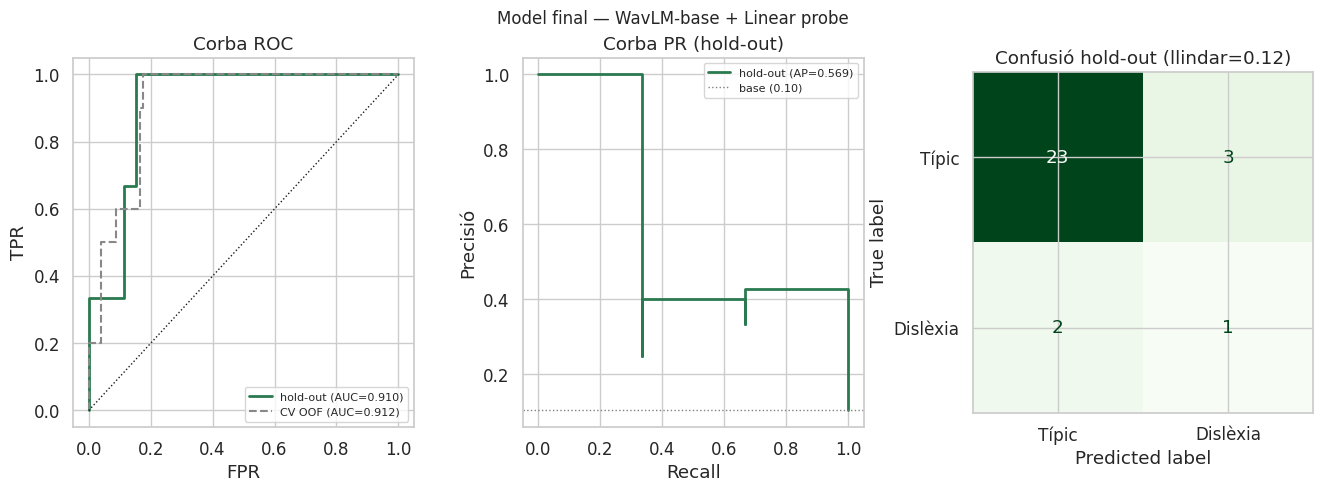


Mètriques hold-out amb el llindar derivat de la CV (F2 màx. OOF):
  F2 (clínic)   : 0.312
  F1            : 0.286
  Recall        : 0.333
  Especificitat : 0.885
  Bal. accuracy : 0.609

Nota: amb només 3 positius al hold-out, les mètriques de llindar són
orientatives; la xifra de referència és l'AUC-ROC de CV amb el seu IC.


In [ ]:
from sklearn.metrics import (roc_curve, auc as sk_auc, precision_recall_curve,
                             ConfusionMatrixDisplay, f1_score, fbeta_score,
                             balanced_accuracy_score, recall_score)

oof_probs  = head_results[winner_name]["oof"]
oof_labels = np.asarray(y_subj_train).astype(int)

# Llindar de decisió derivat de les prediccions OUT-OF-FOLD del cap guanyador
prec_oof, rec_oof, thr_oof = precision_recall_curve(oof_labels, oof_probs)
_f2 = (5 * prec_oof[:-1] * rec_oof[:-1]) / (4 * prec_oof[:-1] + rec_oof[:-1] + 1e-8)
thr_star = float(thr_oof[int(np.nanargmax(_f2))]) if len(thr_oof) else 0.5
print(f"Llindar* (F2 màx. sobre OOF): {thr_star:.3f}")

y_pred_hold = (p_hold >= thr_star).astype(int)

fig = plt.figure(figsize=(16, 4.8))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.32)
ax_roc, ax_pr, ax_cm = (fig.add_subplot(gs[0, i]) for i in range(3))

# (1) ROC — hold-out + OOF de referència
fpr, tpr, _   = roc_curve(y_subj_hold, p_hold)
fpr_o, tpr_o, _ = roc_curve(oof_labels, oof_probs)
ax_roc.plot(fpr, tpr, color="#2a7a4f", lw=2,
            label=f"hold-out (AUC={sk_auc(fpr, tpr):.3f})")
ax_roc.plot(fpr_o, tpr_o, color="#888", lw=1.5, ls="--",
            label=f"CV OOF (AUC={sk_auc(fpr_o, tpr_o):.3f})")
ax_roc.plot([0, 1], [0, 1], "k:", lw=1)
ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
ax_roc.set_title("Corba ROC"); ax_roc.legend(fontsize=8)

# (2) PR — hold-out
pr_p, pr_r, _ = precision_recall_curve(y_subj_hold, p_hold)
ax_pr.step(pr_r, pr_p, color="#2a7a4f", lw=2, where="post",
           label=f"hold-out (AP={sk_auc(pr_r, pr_p):.3f})")
base = float(np.mean(y_subj_hold))
ax_pr.axhline(base, color="gray", ls=":", lw=1, label=f"base ({base:.2f})")
ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precisió")
ax_pr.set_title("Corba PR (hold-out)"); ax_pr.legend(fontsize=8)

# (3) Matriu de confusió — hold-out
ConfusionMatrixDisplay.from_predictions(
    y_subj_hold, y_pred_hold, display_labels=["Típic", "Dislèxia"],
    colorbar=False, ax=ax_cm, cmap="Greens")
ax_cm.set_title(f"Confusió hold-out (llindar={thr_star:.2f})")

plt.suptitle(f"Model final — WavLM-base + {winner_name}", fontsize=12)
plt.savefig(OUTPUTS / "final_model_holdout_eval.pdf", bbox_inches="tight")
plt.show()

# Mètriques dependents del llindar (hold-out
def _specificity(yt, yp):
    tn = int(np.sum((yt == 0) & (yp == 0)))
    fp = int(np.sum((yt == 0) & (yp == 1)))
    return tn / max(tn + fp, 1)

print("\nMètriques hold-out amb el llindar derivat de la CV (F2 màx. OOF):")
print(f"  F2 (clínic)   : {fbeta_score(y_subj_hold, y_pred_hold, beta=2, zero_division=0):.3f}")
print(f"  F1            : {f1_score(y_subj_hold, y_pred_hold, zero_division=0):.3f}")
print(f"  Recall        : {recall_score(y_subj_hold, y_pred_hold, zero_division=0):.3f}")
print(f"  Especificitat : {_specificity(y_subj_hold, y_pred_hold):.3f}")
print(f"  Bal. accuracy : {balanced_accuracy_score(y_subj_hold, y_pred_hold):.3f}")
print("\nNota: amb només 3 positius al hold-out, les mètriques de llindar són")
print("orientatives; la xifra de referència és l'AUC-ROC de CV amb el seu IC.")

### 3.2 Resum consolidat de la selecció

In [32]:
# ── Resum consolidat de tota la cadena de decisió del bloc d'espectrogrames ──
from sklearn.metrics import roc_auc_score, average_precision_score

print("=" * 72)
print("   SELECCIÓ DE MODEL — BLOC D'ESPECTROGRAMES (resum)")
print("=" * 72)

print("\n1) DADES")
print(f"   Fragments: {len(X_wav_all)}  "
      f"(finestres de {WINDOW_S:.0f}s, stride {STRIDE_S:.1f}s)")
print(f"   Subjectes train: {len(subj_train)} ({int(y_subj_train.sum())} dislèxia)  |  "
      f"hold-out: {len(subj_hold)} ({int(y_subj_hold.sum())} dislèxia)")

print("\n2) BACKBONE  (linear probe, CV de subjecte)")
for name in BACKBONES:
    r = cmp_results[name]
    star = "  <-- triat" if name == winner else ""
    print(f"   {name:10s} AUC-ROC={r['roc']:.3f} "
          f"[{r['roc_ci'][0]:.2f},{r['roc_ci'][1]:.2f}]  p={r['p_roc']:.3f}{star}")

print("\n3) CAP DE CLASSIFICACIÓ  (backbone WavLM-base fixat)")
for cname in ALL_CAPS:
    r = head_results[cname]
    star = "  <-- triat" if cname == winner_name else ""
    print(f"   {cname:20s} AUC-ROC={r['roc']:.3f} "
          f"[{r['roc_ci'][0]:.2f},{r['roc_ci'][1]:.2f}]  p={r['p_roc']:.3f}{star}")

print("\n4) MODEL FINAL")
print(f"   WavLM-base (congelat) + {winner_name}")
print(f"   CV  AUC-ROC = {head_results[winner_name]['roc']:.3f}  "
      f"IC95=[{head_results[winner_name]['roc_ci'][0]:.2f},"
      f"{head_results[winner_name]['roc_ci'][1]:.2f}]  "
      f"p={head_results[winner_name]['p_roc']:.3f}")
try:
    from sklearn.metrics import fbeta_score, recall_score
    _y_pred_ho = (p_hold >= thr_star).astype(int)
    _f1_ho  = f1_score(y_subj_hold, _y_pred_ho, zero_division=0)
    _f2_ho  = fbeta_score(y_subj_hold, _y_pred_ho, beta=2, zero_division=0)
    _sens_ho = recall_score(y_subj_hold, _y_pred_ho, zero_division=0)
    print(f"   Hold-out  AUC-ROC = {roc_auc_score(y_subj_hold, p_hold):.3f}  "
          f"AUC-PR = {average_precision_score(y_subj_hold, p_hold):.3f}  "
          f"F1 = {_f1_ho:.3f}  F2 = {_f2_ho:.3f}  "
          f"Sensibilitat = {_sens_ho:.3f}  "
          f"(llindar={thr_star:.3f}, n={len(y_subj_hold)}, pos={int(y_subj_hold.sum())})")
except ValueError:
    print("   Hold-out amb una sola classe; AUC indefinit.")
print("=" * 72)
print("Artefactes desats a outputs/: backbone_comparison.csv, head_comparison.csv,")
print("final_model*.{joblib,pt,json}, final_model_holdout_eval.pdf, final_model_reliability.pdf")

   SELECCIÓ DE MODEL — BLOC D'ESPECTROGRAMES (resum)

1) DADES
   Fragments: 3544  (finestres de 5s, stride 2.5s)
   Subjectes train: 112 (10 dislèxia)  |  hold-out: 29 (3 dislèxia)

2) BACKBONE  (linear probe, CV de subjecte)
   PANNs      AUC-ROC=0.722 [0.53,0.90]  p=0.026
   WavLM      AUC-ROC=0.912 [0.84,0.97]  p=0.002  <-- triat
   wav2vec2   AUC-ROC=0.673 [0.48,0.85]  p=0.074

3) CAP DE CLASSIFICACIÓ  (backbone WavLM-base fixat)
   Linear probe         AUC-ROC=0.912 [0.84,0.97]  p=0.002  <-- triat
   MeanPool-MIL         AUC-ROC=0.899 [0.81,0.97]  p=0.010
   GatedAttention-MIL   AUC-ROC=0.896 [0.81,0.96]  p=0.010

4) MODEL FINAL
   WavLM-base (congelat) + Linear probe
   CV  AUC-ROC = 0.912  IC95=[0.84,0.97]  p=0.002
   Hold-out  AUC-ROC = 0.910  AUC-PR = 0.610  F1 = 0.286  F2 = 0.312  Sensibilitat = 0.333  (llindar=0.117, n=29, pos=3)
Artefactes desats a outputs/: backbone_comparison.csv, head_comparison.csv,
final_model*.{joblib,pt,json}, final_model_holdout_eval.pdf, final_mod